In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim.lr_scheduler import StepLR
from torchvision import datasets, transforms
from torch.utils.data import DataLoader
from torch.utils.tensorboard import SummaryWriter
import matplotlib.pyplot as plt
import numpy as np

# Define CNN architecture
# Arsitektur CNN dengan dua lapisan konvolusi dan pooling
class CNN(nn.Module):
    def __init__(self, kernel_size, pooling_type):
        super(CNN, self).__init__()
        pool = nn.MaxPool2d if pooling_type == "max" else nn.AvgPool2d
        
        # Lapisan konvolusi pertama dengan 32 filter
        self.conv1 = nn.Conv2d(1, 32, kernel_size=kernel_size, padding=kernel_size//2)
        # Lapisan pooling pertama untuk mengurangi dimensi fitur
        self.pool1 = pool(2, 2)
        # Lapisan konvolusi kedua dengan 64 filter
        self.conv2 = nn.Conv2d(32, 64, kernel_size=kernel_size, padding=kernel_size//2)
        # Lapisan pooling kedua untuk mengurangi dimensi fitur
        self.pool2 = pool(2, 2)
        # Lapisan fully connected pertama
        self.fc1 = nn.Linear(64 * 7 * 7, 128)
        # Lapisan fully connected kedua
        self.fc2 = nn.Linear(128, 10)

    def forward(self, x):
        x = torch.relu(self.pool1(self.conv1(x)))
        x = torch.relu(self.pool2(self.conv2(x)))
        x = x.view(-1, 64 * 7 * 7)
        x = torch.relu(self.fc1(x))
        x = self.fc2(x)
        return x

# Load Fashion MNIST dataset
# Mengatur transformasi untuk dataset Fashion MNIST
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,))
])

# Memuat dataset Fashion MNIST
train_dataset = datasets.FashionMNIST(root="./data", train=True, download=True, transform=transform)
test_dataset = datasets.FashionMNIST(root="./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

# Fungsi untuk melatih dan mengevaluasi model
# Menggunakan kombinasi hyperparameter tertentu

def train_and_evaluate(kernel_size, pooling_type, optimizer_type, epochs, early_stop_patience):
    model = CNN(kernel_size=kernel_size, pooling_type=pooling_type).to(device)
    criterion = nn.CrossEntropyLoss()

    if optimizer_type == "SGD":
        optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9)
    elif optimizer_type == "RMSProp":
        optimizer = optim.RMSprop(model.parameters(), lr=0.001)
    else:
        optimizer = optim.Adam(model.parameters(), lr=0.001)

    scheduler = StepLR(optimizer, step_size=10, gamma=0.1)
    
    best_loss = float("inf")
    patience = 0

    train_loss, test_loss, test_accuracy = [], [], []

    for epoch in range(epochs):
        model.train()
        running_loss = 0.0
        for images, labels in train_loader:
            images, labels = images.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(images)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_loss.append(running_loss / len(train_loader))

        model.eval()
        correct, total, running_test_loss = 0, 0, 0.0
        with torch.no_grad():
            for images, labels in test_loader:
                images, labels = images.to(device), labels.to(device)
                outputs = model(images)
                loss = criterion(outputs, labels)
                running_test_loss += loss.item()
                _, predicted = torch.max(outputs, 1)
                total += labels.size(0)
                correct += (predicted == labels).sum().item()
        test_loss.append(running_test_loss / len(test_loader))
        test_accuracy.append(100 * correct / total)

        if test_loss[-1] < best_loss:
            best_loss = test_loss[-1]
            patience = 0
        else:
            patience += 1

        if patience > early_stop_patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        scheduler.step()
        print(f"Epoch {epoch+1}/{epochs}, Train Loss: {train_loss[-1]:.4f}, Test Loss: {test_loss[-1]:.4f}, Test Accuracy: {test_accuracy[-1]:.2f}%")

    return train_loss, test_loss, test_accuracy

# Hyperparameters to test
# Kombinasi kernel size, jenis pooling, optimizer, dan jumlah epoch
kernel_sizes = [3, 5, 7]
pooling_types = ["max", "avg"]
optimizers = ["SGD", "RMSProp", "Adam"]
epochs_list = [5, 50, 100]
early_stop_patience = 5

device = torch.device("cpu")

# Dictionary untuk menyimpan hasil
results = {}

for kernel_size in kernel_sizes:
    for pooling_type in pooling_types:
        for optimizer_type in optimizers:
            for epochs in epochs_list:
                print(f"Training with Kernel Size: {kernel_size}, Pooling: {pooling_type}, Optimizer: {optimizer_type}, Epochs: {epochs}")
                train_loss, test_loss, test_accuracy = train_and_evaluate(kernel_size, pooling_type, optimizer_type, epochs, early_stop_patience)
                results[(kernel_size, pooling_type, optimizer_type, epochs)] = (train_loss, test_loss, test_accuracy)



100%|██████████| 26.4M/26.4M [03:51<00:00, 114kB/s] 


Extracting ./data\FashionMNIST\raw\train-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 29.5k/29.5k [00:00<00:00, 141kB/s]


Extracting ./data\FashionMNIST\raw\train-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 4.42M/4.42M [00:01<00:00, 2.72MB/s]


Extracting ./data\FashionMNIST\raw\t10k-images-idx3-ubyte.gz to ./data\FashionMNIST\raw



100%|██████████| 5.15k/5.15k [00:00<00:00, 5.18MB/s]


Extracting ./data\FashionMNIST\raw\t10k-labels-idx1-ubyte.gz to ./data\FashionMNIST\raw

Training with Kernel Size: 3, Pooling: max, Optimizer: SGD, Epochs: 5
Epoch 1/5, Train Loss: 0.5356, Test Loss: 0.3769, Test Accuracy: 86.46%
Epoch 2/5, Train Loss: 0.3213, Test Loss: 0.3225, Test Accuracy: 88.53%
Epoch 3/5, Train Loss: 0.2746, Test Loss: 0.3031, Test Accuracy: 89.12%
Epoch 4/5, Train Loss: 0.2437, Test Loss: 0.2694, Test Accuracy: 90.30%
Epoch 5/5, Train Loss: 0.2225, Test Loss: 0.2559, Test Accuracy: 90.72%
Training with Kernel Size: 3, Pooling: max, Optimizer: SGD, Epochs: 50
Epoch 1/50, Train Loss: 0.5344, Test Loss: 0.3592, Test Accuracy: 86.90%
Epoch 2/50, Train Loss: 0.3198, Test Loss: 0.3156, Test Accuracy: 88.50%
Epoch 3/50, Train Loss: 0.2696, Test Loss: 0.3447, Test Accuracy: 87.00%
Epoch 4/50, Train Loss: 0.2414, Test Loss: 0.2645, Test Accuracy: 90.48%
Epoch 5/50, Train Loss: 0.2162, Test Loss: 0.2546, Test Accuracy: 90.81%
Epoch 6/50, Train Loss: 0.1967, Test Loss: 0.

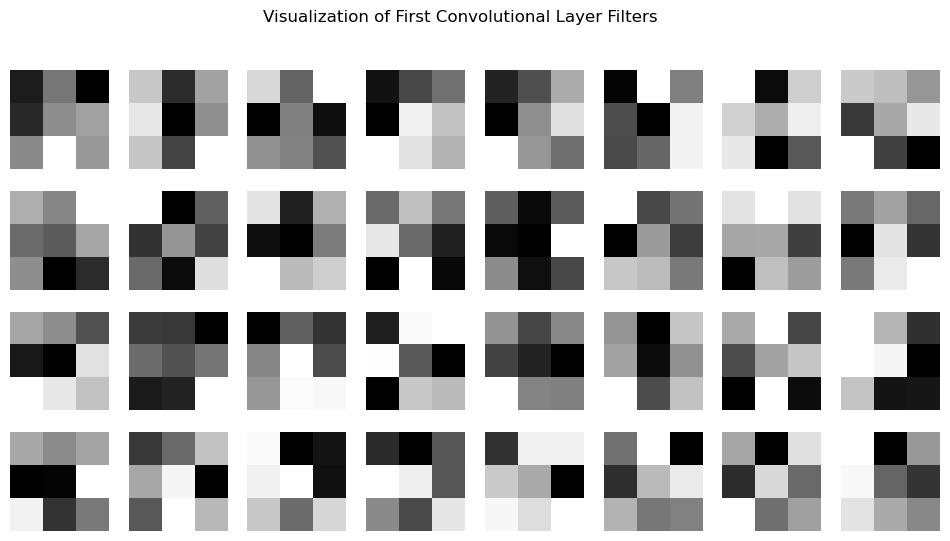

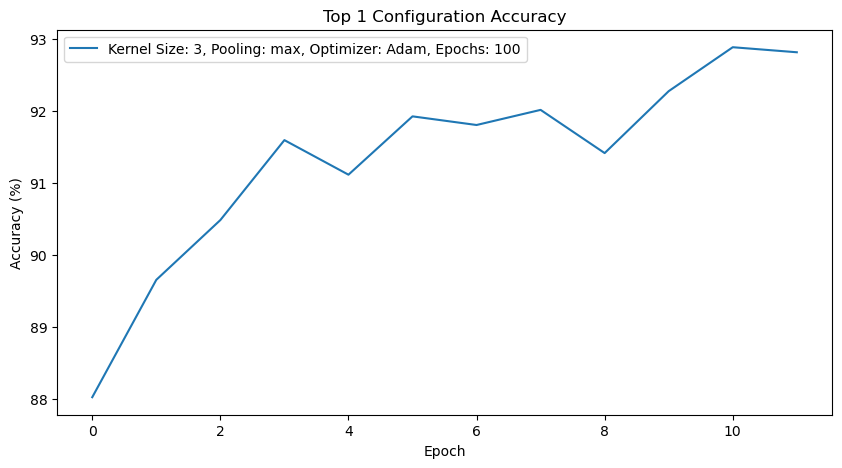

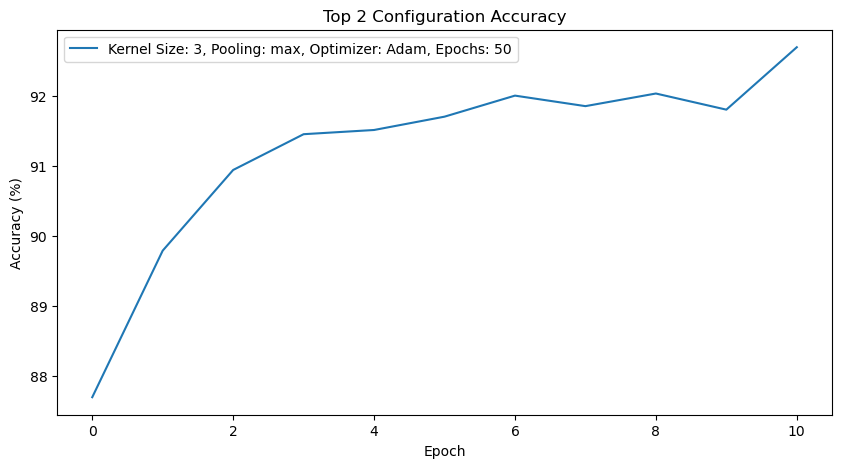

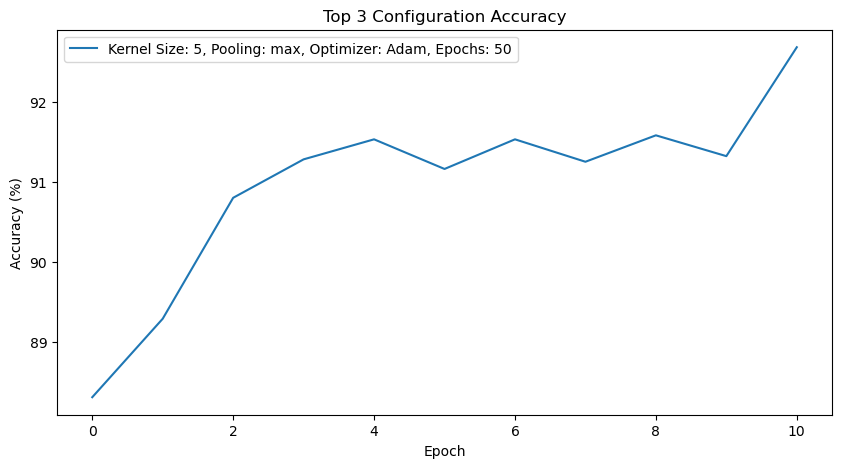

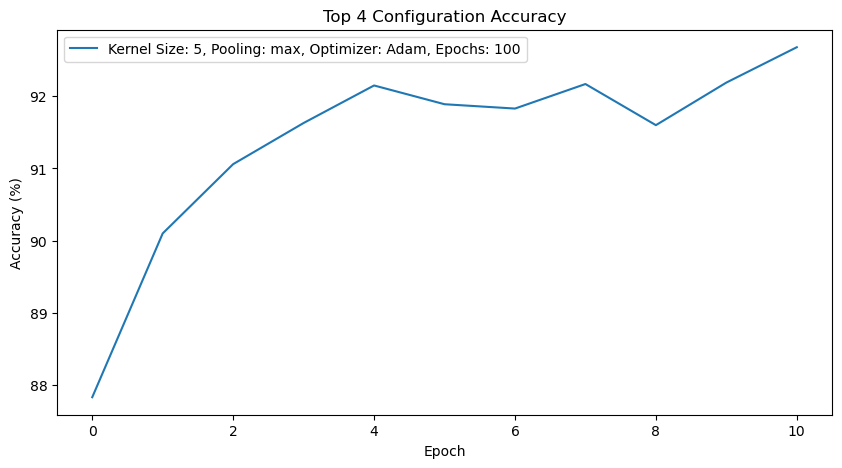

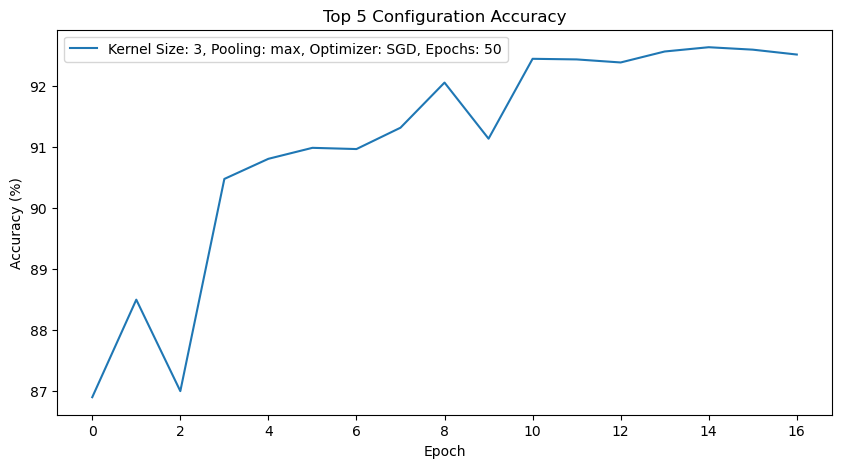

In [2]:
# Menentukan 5 parameter terbaik berdasarkan akurasi
best_results = sorted(results.items(), key=lambda x: max(x[1][2]), reverse=True)[:5]

# Visualisasi kernel filter pertama
model_example = CNN(kernel_size=3, pooling_type="max").to(device)
filters = model_example.conv1.weight.data.cpu()
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < filters.size(0):
        ax.imshow(filters[i, 0, :, :], cmap='gray')
        ax.axis('off')
plt.suptitle("Visualization of First Convolutional Layer Filters")
plt.show()

# Visualisasi hubungan kernel size dengan akurasi untuk parameter terbaik
for i, (key, value) in enumerate(best_results):
    kernel_size, pooling_type, optimizer_type, epochs = key
    train_loss, test_loss, test_accuracy = value

    plt.figure(figsize=(10, 5))
    plt.plot(test_accuracy, label=f"Kernel Size: {kernel_size}, Pooling: {pooling_type}, Optimizer: {optimizer_type}, Epochs: {epochs}")
    plt.title(f"Top {i+1} Configuration Accuracy")
    plt.xlabel("Epoch")
    plt.ylabel("Accuracy (%)")
    plt.legend()
    plt.show()
